In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
numbers = np.arange(1, 100)
results = numbers ** 2

In [4]:
print(numbers[94:100])
print(results[94:100])


[95 96 97 98 99]
[9025 9216 9409 9604 9801]


In [5]:
from sklearn.preprocessing import MinMaxScaler

x = numbers.reshape(-1, 1)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
print(x_scaled[94:100])

[[0.95918367]
 [0.96938776]
 [0.97959184]
 [0.98979592]
 [1.        ]]


'Normalization = MinMaxScaler
xn = (x - xmin)/(xmax - xmin)

'Standardization = StandardScaler
xs = (x - xmean)/(xmean - standard deviation)

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled, results, test_size=0.2, random_state = 42)

In [8]:
x_train.shape

(79, 1)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [12]:
model = Sequential([
    Input(shape=(1,)),
    Dense(units=128, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='linear')
])

In [13]:
from tensorflow.keras.optimizers import Adam
model.compile(
    loss= 'mse',
    optimizer=Adam(learning_rate=0.02),
    metrics=['mse']
)

#loss = 18801514

In [27]:
model.fit(x_train, y_train, epochs=300)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 19511698.0000 - mse: 19511698.0000 
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19479204.0000 - mse: 19479204.0000 
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19404710.0000 - mse: 19404710.0000 
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19270712.0000 - mse: 19270712.0000 
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19022434.0000 - mse: 19022434.0000 
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18663346.0000 - mse: 18663346.0000 
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18086264.0000 - mse: 18086264.0000 
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17371730.0000 - mse: 17371730.0000 
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16381983.0000 - mse: 16381983.0000 
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15004222.0000 - mse: 15004222.0000 
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13436577.0

In [28]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


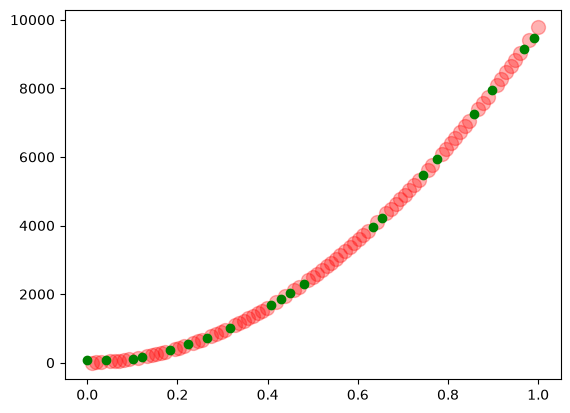

In [30]:
plt.scatter(x_train, y_train, s=100, color='red', alpha=0.3)
plt.scatter(x_test, y_pred, color='green')